# 4. Modelo base

El modelo base es una regresión logística dentro de un `Pipeline` (Pedregosa et al., 2011).
Se evalúa frente a tres referencias de dificultad creciente.

| Referencia | Qué representa |
|---|---|
| `DummyClassifier` | predice siempre la clase mayoritaria |
| Persistencia | dentro de quince días el río estará como hoy |
| Curva de gasto sólido | el método estándar del dominio |

La persistencia es la referencia exigente en series fluviales. Con una autocorrelación de
0,92 a quince días, un modelo puede alcanzar un acierto elevado limitándose a repetir el
estado actual, de modo que superarla es lo que acredita capacidad predictiva.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import json, sys

sys.path.insert(0, ".")
from src.config import (SEED, DATOS_PROC, FIGURAS, ESTACION_OBJETIVO,
                        FECHA_CORTE_TEST, GAP_DIAS, HORIZONTE,
                        fijar_semillas, estilo_graficos)

fijar_semillas(SEED)
estilo_graficos()

dfx = pd.read_csv(DATOS_PROC / "features.csv", parse_dates=["fecha"])
with open(DATOS_PROC / "parametros.json", encoding="utf-8") as f:
    par = json.load(f)

Q_EF = par["Q_EF"]
LIM = tuple(par["LIM"])
A_OF, B_OF = par["A_OF"], par["B_OF"]
BASE_COLS, DOM_COLS = par["BASE_COLS"], par["DOM_COLS"]
TODAS = BASE_COLS + DOM_COLS

print(f"{len(dfx):,} filas, {len(TODAS)} predictores")
print(f"Q_ef = {Q_EF:,.0f} m³/s   banda = [{LIM[0]:,.0f} - {LIM[1]:,.0f}]")

31,475 filas, 43 predictores
Q_ef = 9,954 m³/s   banda = [8,461 - 11,448]


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             brier_score_loss, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

corte = pd.Timestamp(FECHA_CORTE_TEST)
inicio_test = corte + pd.Timedelta(days=GAP_DIAS)

dm = dfx.dropna(subset=["y"])
TR = dm[dm.fecha < corte]
TE = dm[dm.fecha >= inicio_test]

Xtr, ytr = TR[TODAS], TR.y.astype(int)
Xte, yte = TE[TODAS], TE.y.astype(int)

print(f"Train: {len(Xtr):,} obs.  prevalencia {ytr.mean():.2%}")
print(f"Test:  {len(Xte):,} obs.  prevalencia {yte.mean():.2%}")

Train: 25,364 obs.  prevalencia 25.67%
Test:  6,066 obs.  prevalencia 24.86%


In [3]:
# La validacion cruzada respeta la estructura temporal
cv = TimeSeriesSplit(n_splits=5, gap=GAP_DIAS)

print(f"TimeSeriesSplit(n_splits=5, gap={GAP_DIAS})")
for i, (a, b) in enumerate(cv.split(Xtr), 1):
    print(f"  pliegue {i}: train n = {len(a):>6,}  validación n = {len(b):>6,}")

TimeSeriesSplit(n_splits=5, gap=30)
  pliegue 1: train n =  4,199  validación n =  4,227
  pliegue 2: train n =  8,426  validación n =  4,227
  pliegue 3: train n = 12,653  validación n =  4,227
  pliegue 4: train n = 16,880  validación n =  4,227
  pliegue 5: train n = 21,107  validación n =  4,227


In [4]:
def modelo_base():
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("esc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)),
    ])


class Persistencia:
    """El estado de hoy se mantiene dentro de h dias."""
    def __init__(self, lim): self.lim = lim
    def fit(self, X, y=None): return self
    def predict(self, X): return X[ESTACION_OBJETIVO].between(*self.lim).astype(int).values
    def predict_proba(self, X):
        p = self.predict(X).astype(float)
        return np.column_stack([1 - p, p])


class GastoSolido:
    """Clasifica por la carga estimada con la curva oficial."""
    def __init__(self, a, b, lim): self.a, self.b, self.lim = a, b, lim
    def fit(self, X, y=None): return self
    def predict(self, X):
        qs = self.a * X[ESTACION_OBJETIVO].clip(lower=1) ** self.b
        lo, hi = self.a * self.lim[0]**self.b, self.a * self.lim[1]**self.b
        return ((qs >= lo) & (qs <= hi)).astype(int).values
    def predict_proba(self, X):
        p = self.predict(X).astype(float)
        return np.column_stack([1 - p, p])


def evaluar(modelo, Xa, ya, Xb, yb, nombre, cols):
    es_dominio = isinstance(modelo, (Persistencia, GastoSolido))
    modelo.fit(Xa if es_dominio else Xa[cols], ya)
    Xp = Xb if es_dominio else Xb[cols]
    yp = modelo.predict(Xp)
    ys = modelo.predict_proba(Xp)[:, 1]
    return {"modelo": nombre,
            "accuracy": accuracy_score(yb, yp),
            "precision": precision_score(yb, yp, zero_division=0),
            "recall": recall_score(yb, yp, zero_division=0),
            "f1": f1_score(yb, yp, zero_division=0),
            "roc_auc": roc_auc_score(yb, ys),
            "pr_auc": average_precision_score(yb, ys),
            "brier": brier_score_loss(yb, np.clip(ys, 0, 1))}, yp, ys

## 4.1 Desempeño en el conjunto de prueba

In [5]:
XtrF = TR[TODAS + [ESTACION_OBJETIVO]]
XteF = TE[TODAS + [ESTACION_OBJETIVO]]

modelos = {
    "dummy": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "persistencia": Persistencia(LIM),
    "gasto sólido": GastoSolido(A_OF, B_OF, LIM),
    "regresión logística": modelo_base(),
}

resultados, preds = [], {}
for nombre, m in modelos.items():
    r, yp, ys = evaluar(m, XtrF, ytr, XteF, yte, nombre, TODAS)
    resultados.append(r)
    preds[nombre] = (yp, ys)

comp = pd.DataFrame(resultados).set_index("modelo")
print(comp.round(4).to_string())
print()
print(f"Ganancia de PR-AUC sobre el dummy:        "
      f"{comp.loc['regresión logística','pr_auc'] - comp.loc['dummy','pr_auc']:+.4f}")
print(f"Ganancia de PR-AUC sobre la persistencia: "
      f"{comp.loc['regresión logística','pr_auc'] - comp.loc['persistencia','pr_auc']:+.4f}")

                     accuracy  precision  recall      f1  roc_auc  pr_auc   brier
modelo                                                                           
dummy                  0.7514     0.0000  0.0000  0.0000   0.5000  0.2486  0.2486
persistencia           0.8826     0.7639  0.7639  0.7639   0.8429  0.6423  0.1174
gasto sólido           0.8826     0.7639  0.7639  0.7639   0.8429  0.6423  0.1174
regresión logística    0.8820     0.6947  0.9370  0.7979   0.9588  0.8717  0.0899

Ganancia de PR-AUC sobre el dummy:        +0.6231
Ganancia de PR-AUC sobre la persistencia: +0.2295


## 4.2 Validación cruzada y contraste de sobreajuste

In [6]:
cvres = cross_validate(modelo_base(), Xtr, ytr, cv=cv,
                       scoring=["accuracy", "f1", "roc_auc", "average_precision"],
                       return_train_score=True)

tabla_cv = pd.DataFrame({
    "pliegue": range(1, 6),
    "train_roc_auc": cvres["train_roc_auc"],
    "val_roc_auc": cvres["test_roc_auc"],
    "val_f1": cvres["test_f1"],
    "val_pr_auc": cvres["test_average_precision"]})

print(tabla_cv.round(4).to_string(index=False))
print(f"\nROC-AUC en validación: {cvres['test_roc_auc'].mean():.4f} ± {cvres['test_roc_auc'].std():.4f}")

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_rel']. At least one non-missing value is needed for imputati

 pliegue  train_roc_auc  val_roc_auc  val_f1  val_pr_auc
       1         0.9835       0.9191  0.7637      0.7392
       2         0.9669       0.9077  0.7523      0.7661
       3         0.9601       0.8992  0.7100      0.7297
       4         0.9608       0.9659  0.8127      0.8712
       5         0.9626       0.9360  0.7659      0.8274

ROC-AUC en validación: 0.9256 ± 0.0236


In [7]:
# Prueba t pareada sobre los cinco pliegues
dif = cvres["train_roc_auc"] - cvres["test_roc_auc"]
t_stat, p_val = st.ttest_rel(cvres["train_roc_auc"], cvres["test_roc_auc"])
ic = st.t.interval(0.95, len(dif) - 1, loc=dif.mean(), scale=st.sem(dif))

print(f"Diferencia media train - validación: {dif.mean():+.4f}")
print(f"t = {t_stat:.3f}   p = {p_val:.4f}")
print(f"IC 95%: [{ic[0]:+.4f}, {ic[1]:+.4f}]")
print("Lectura:", "diferencia significativa" if p_val < 0.05 else "sin evidencia de sobreajuste")

Diferencia media train - validación: +0.0412
t = 3.068   p = 0.0374
IC 95%: [+0.0039, +0.0785]
Lectura: diferencia significativa


La prueba detecta una diferencia estadísticamente significativa entre entrenamiento y
validación, de modo que conviene separar la significancia de la magnitud del efecto.

La diferencia media de área bajo la curva ROC ronda los cuatro puntos porcentuales, por
debajo del rango de 5 a 10 % que las notas del curso consideran aceptable y lejos del 15 a
20 % que señalaría sobreajuste preocupante. La prueba opera sobre diferencias muy
consistentes entre pliegues, con dispersión reducida, y con datos de esta naturaleza casi
cualquier diferencia sistemática resulta significativa. De ahí que se reporte también el
intervalo de confianza, cuyo límite inferior queda próximo a cero.

La curva de aprendizaje y el desempeño sobre el conjunto de prueba, un periodo futuro de
dieciséis años nunca visto, completan el diagnóstico.

## 4.3 Curvas de evaluación

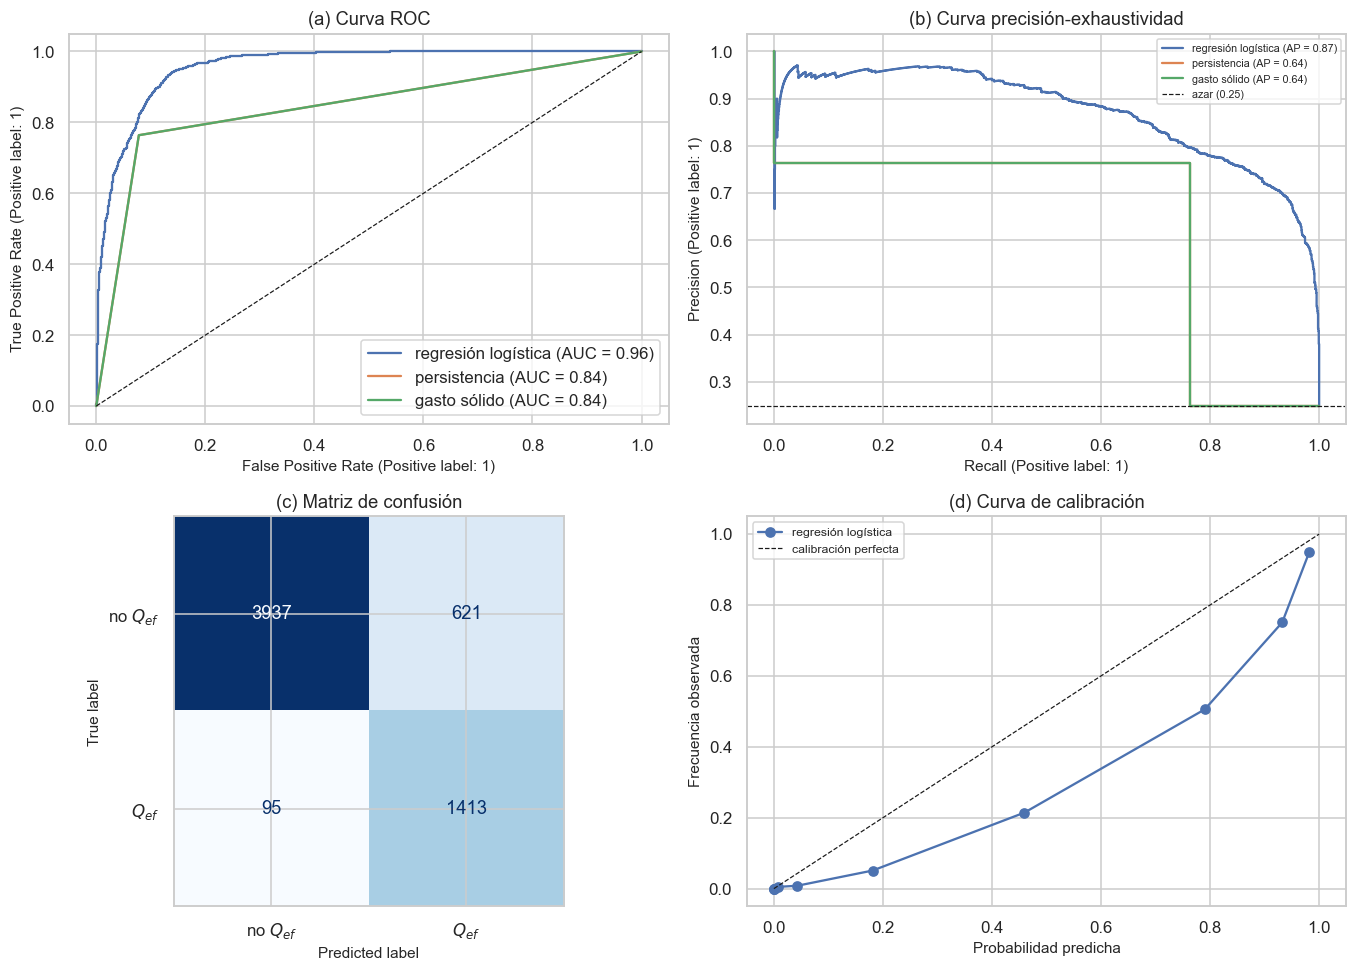

              precision    recall  f1-score   support

     no Q_ef      0.976     0.864     0.917      4558
        Q_ef      0.695     0.937     0.798      1508

    accuracy                          0.882      6066
   macro avg      0.836     0.900     0.857      6066
weighted avg      0.906     0.882     0.887      6066



In [8]:
yp_l, ys_l = preds["regresión logística"]

fig, ax = plt.subplots(2, 2, figsize=(12.5, 9))

for nombre in ["regresión logística", "persistencia", "gasto sólido"]:
    RocCurveDisplay.from_predictions(yte, preds[nombre][1], name=nombre, ax=ax[0, 0])
ax[0, 0].plot([0, 1], [0, 1], "k--", lw=.8)
ax[0, 0].set_title("(a) Curva ROC")

for nombre in ["regresión logística", "persistencia", "gasto sólido"]:
    PrecisionRecallDisplay.from_predictions(yte, preds[nombre][1], name=nombre, ax=ax[0, 1])
ax[0, 1].axhline(yte.mean(), color="k", ls="--", lw=.8, label=f"azar ({yte.mean():.2f})")
ax[0, 1].set_title("(b) Curva precisión-exhaustividad")
ax[0, 1].legend(fontsize=7)

ConfusionMatrixDisplay(confusion_matrix(yte, yp_l),
                       display_labels=["no $Q_{ef}$", "$Q_{ef}$"]).plot(
    ax=ax[1, 0], cmap="Blues", colorbar=False)
ax[1, 0].set_title("(c) Matriz de confusión")

pt, pp = calibration_curve(yte, np.clip(ys_l, 0, 1), n_bins=10, strategy="quantile")
ax[1, 1].plot(pp, pt, "o-", label="regresión logística")
ax[1, 1].plot([0, 1], [0, 1], "k--", lw=.8, label="calibración perfecta")
ax[1, 1].set(xlabel="Probabilidad predicha", ylabel="Frecuencia observada",
             title="(d) Curva de calibración")
ax[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURAS / "evaluacion.png", dpi=150)
plt.show()

print(classification_report(yte, yp_l, target_names=["no Q_ef", "Q_ef"], digits=3))

## 4.4 Intervalos de confianza

In [9]:
def ic_bootstrap(yt, ys, metrica, n_boot=2000, alfa=0.05):
    rng = np.random.default_rng(SEED)
    yt, ys = np.asarray(yt), np.asarray(ys)
    vals = []
    for _ in range(n_boot):
        i = rng.integers(0, len(yt), len(yt))
        if len(np.unique(yt[i])) < 2:
            continue
        vals.append(metrica(yt[i], ys[i]))
    lo, hi = np.percentile(vals, [100*alfa/2, 100*(1-alfa/2)])
    return np.mean(vals), lo, hi

f1_umbral = lambda a, b: f1_score(a, (np.asarray(b) >= 0.5).astype(int), zero_division=0)

filas = []
for nombre in modelos:
    _, ys = preds[nombre]
    for met, fn in [("ROC-AUC", roc_auc_score), ("PR-AUC", average_precision_score),
                    ("F1", f1_umbral)]:
        m, lo, hi = ic_bootstrap(yte, ys, fn)
        filas.append({"modelo": nombre, "metrica": met,
                      "estimacion": m, "IC95_inf": lo, "IC95_sup": hi})

pd.DataFrame(filas).round(4)

,modelo,metrica,estimacion,IC95_inf,IC95_sup
0,dummy,ROC-AUC,0.5000,0.5000,0.5000
1,dummy,PR-AUC,0.2486,0.2379,0.2593
2,dummy,F1,0.0000,0.0000,0.0000
3,persistencia,ROC-AUC,0.8429,0.8318,0.8545
4,persistencia,PR-AUC,0.6425,0.6195,0.6641
5,persistencia,F1,0.7640,0.7465,0.7804
6,gasto sólido,ROC-AUC,0.8429,0.8318,0.8545
7,gasto sólido,PR-AUC,0.6425,0.6195,0.6641
8,gasto sólido,F1,0.7640,0.7465,0.7804
9,regresión logística,ROC-AUC,0.9588,0.9544,0.9631


## 4.5 Curva de aprendizaje y residuos

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'pto_salgar_t21' 'pto_salgar_d3' 'pto_salgar_rel'
 'san_roque_t10' 'san_roque_d3' 'san_roque_rel' 'tres_cruces_t16'
 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'pto_salgar_t21' 'pto_salgar_d3' 'pto_salgar_rel'
 'san_roque_t10' 'san_roque_d3' 'san_roque_rel' 'tres_cruces_t16'
 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\en

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'pto_salgar_t21' 'pto_salgar_d3' 'pto_salgar_rel'
 'san_roque_t10' 'san_roque_d3' 'san_roque_rel' 'tres_cruces_t16'
 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'pto_salgar_t21' 'pto_salgar_d3' 'pto_salgar_rel'
 'san_roque_t10' 'san_roque_d3' 'san_roque_rel' 'tres_cruces_t16'
 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\en

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

...

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'pto_salgar_t21' 'pto_salgar_d3' 'pto_salgar_rel'
 'san_roque_t10' 'san_roque_d3' 'san_roque_rel' 'tres_cruces_t16'
 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.p

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'pto_salgar_t21' 'pto_salgar_d3' 'pto_salgar_rel'
 'san_roque_t10' 'san_roque_d3' 'san_roque_rel' 'tres_cruces_t16'
 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.p

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any o

C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['coyongal_t7' 'coyongal_d3' 'coyongal_rel' 'el_banco_t12' 'el_banco_d3'
 'el_banco_rel' 'san_roque_t10' 'san_roque_d3' 'san_roque_rel'
 'tres_cruces_t16' 'tres_cruces_d3' 'tres_cruces_rel']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


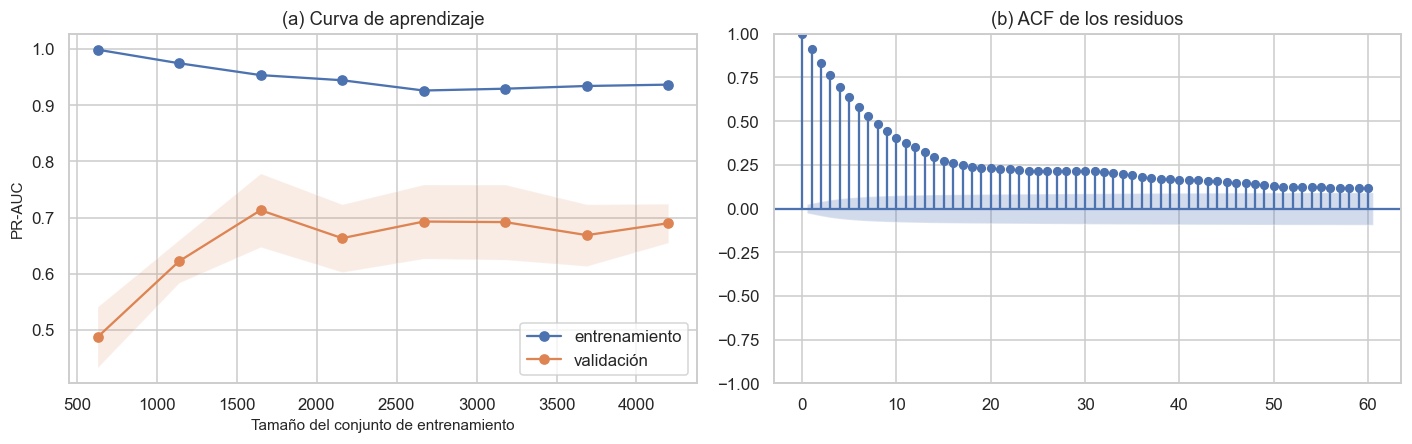

ACF de residuos: lag1 = 0.9142 | lag7 = 0.5273 | lag30 = 0.2130


In [10]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

tam, sc_tr, sc_va = learning_curve(modelo_base(), Xtr, ytr, cv=cv,
                                   scoring="average_precision",
                                   train_sizes=np.linspace(0.15, 1.0, 8))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

ax[0].plot(tam, sc_tr.mean(1), "o-", label="entrenamiento")
ax[0].plot(tam, sc_va.mean(1), "o-", label="validación")
ax[0].fill_between(tam, sc_tr.mean(1)-sc_tr.std(1), sc_tr.mean(1)+sc_tr.std(1), alpha=.15)
ax[0].fill_between(tam, sc_va.mean(1)-sc_va.std(1), sc_va.mean(1)+sc_va.std(1), alpha=.15)
ax[0].set(xlabel="Tamaño del conjunto de entrenamiento", ylabel="PR-AUC",
          title="(a) Curva de aprendizaje")
ax[0].legend()

residuo = yte.values - np.clip(ys_l, 0, 1)
plot_acf(residuo, lags=60, ax=ax[1])
ax[1].set_title("(b) ACF de los residuos")

plt.tight_layout()
plt.savefig(FIGURAS / "aprendizaje_residuos.png", dpi=150)
plt.show()

ar = acf(residuo, nlags=30, fft=True)
print(f"ACF de residuos: lag1 = {ar[1]:.4f} | lag7 = {ar[7]:.4f} | lag30 = {ar[30]:.4f}")

## 4.6 Coeficientes del modelo

In [11]:
mdl = modelo_base().fit(Xtr, ytr)
coef = pd.DataFrame({"variable": TODAS, "coeficiente": mdl.named_steps["clf"].coef_[0]})
coef["odds_ratio"] = np.exp(coef.coeficiente)

coef.reindex(coef.coeficiente.abs().sort_values(ascending=False).index).head(15).round(4)

,variable,coeficiente,odds_ratio
41,dist_qef_lag7,4.5258,92.3680
38,dist_qef,-3.9754,0.0188
39,dist_qef_rel,-3.9754,0.0188
9,calamar_media7,2.5997,13.4592
13,calamar_media90,2.1005,8.1703
4,calamar_lag7,1.8425,6.3121
40,calamar_cuad,-1.6348,0.1950
7,calamar_lag30,-1.4803,0.2276
3,calamar_lag5,-1.4286,0.2396
1,calamar_lag2,-1.2784,0.2785


## 4.7 Sensibilidad al horizonte

El caudal diario de un río grande es muy persistente, de modo que predecir a un día vista
se resuelve repitiendo el estado actual. El caudal de hoy está legítimamente disponible
hoy, así que no constituye fuga, pero a horizonte corto el ejercicio pierde contenido. El
análisis siguiente cuantifica cómo se endurece el problema al alejarse en el tiempo.

In [12]:
filas = []
for h in (1, 7, 15, 30, 60):
    z = dfx.copy()
    z["y"] = z[ESTACION_OBJETIVO].between(*LIM).astype(float).shift(-h)
    z = z.dropna(subset=["y"])
    a_ = z[z.fecha < corte]
    b_ = z[z.fecha >= inicio_test]
    yb = b_.y.astype(int)

    for nombre, cols in [("solo lineales en Q", BASE_COLS), ("con dominio", TODAS)]:
        m = modelo_base().fit(a_[cols], a_.y.astype(int))
        s = m.predict_proba(b_[cols])[:, 1]
        filas.append({"horizonte": f"t+{h}", "predictores": nombre,
                      "PR_AUC": average_precision_score(yb, s)})

    pm = Persistencia(LIM)
    filas.append({"horizonte": f"t+{h}", "predictores": "persistencia",
                  "PR_AUC": average_precision_score(yb, pm.predict_proba(b_)[:, 1])})

sens = (pd.DataFrame(filas)
        .pivot(index="horizonte", columns="predictores", values="PR_AUC")
        .reindex([f"t+{h}" for h in (1, 7, 15, 30, 60)]))

print(sens.round(4).to_string())

predictores  con dominio  persistencia  solo lineales en Q
horizonte                                                 
t+1               0.9960        0.9621              0.4814
t+7               0.9548        0.8011              0.4834
t+15              0.8717        0.6423              0.4868
t+30              0.6286        0.4395              0.4762
t+60              0.4832        0.2705              0.4591


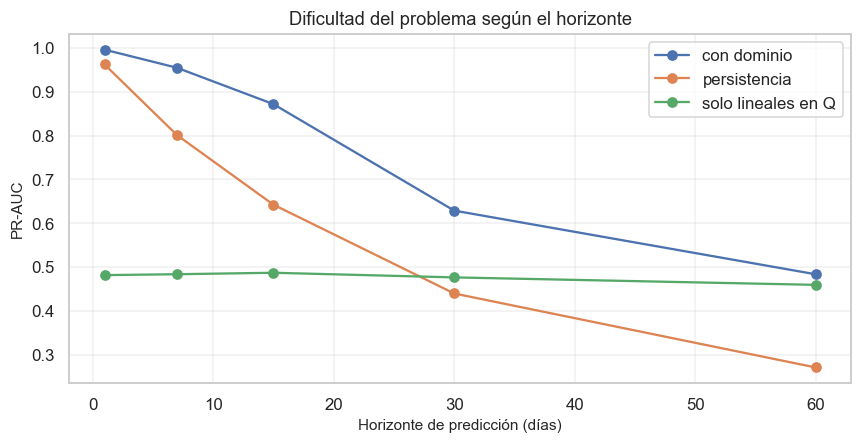

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for c in sens.columns:
    ax.plot([1, 7, 15, 30, 60], sens[c], "o-", label=c)
ax.set(xlabel="Horizonte de predicción (días)", ylabel="PR-AUC",
       title="Dificultad del problema según el horizonte")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIGURAS / "horizonte.png", dpi=150)
plt.show()

## 4.8 Verificación del desempeño

Un desempeño alto admite explicaciones distintas del aprendizaje, por lo que se revisan las
posibles fuentes de inflación.

| Verificación | Resultado |
|---|---|
| Fuga de datos | Se auditó en 3.5: el objetivo está en $t+15$ y todo predictor usa información disponible hasta $t$. La serie de transporte quedó excluida por depender de forma determinista del caudal |
| Comparación con línea base | Se realizó contra tres referencias, dos de ellas propias del dominio hidrológico |
| Estructura temporal en la validación | La partición es cronológica, con intervalo de separación de treinta días, y la validación cruzada emplea `TimeSeriesSplit` |
| Complejidad del conjunto | El registro abarca 86 años y siete estaciones, con régimen bimodal y autocorrelación elevada |
| Dificultad del problema | A horizonte corto resulta trivial, de ahí la elección de quince días y el reporte de la curva completa frente al horizonte |

## 4.9 Limitación de forma funcional del modelo base

El objetivo es una banda de caudales. La regresión logística modela el logit como función
monótona de cada predictor, de modo que solo puede afirmar que a mayor caudal corresponde
mayor probabilidad. La clase positiva exige en cambio que el caudal se mantenga dentro de
un intervalo, condición no monótona que una frontera lineal no representa.

La solución aplicada sustituye el caudal por la distancia al centro de la banda. La
transformación vuelve monótono el problema, puesto que a menor distancia corresponde mayor
probabilidad, y lo pone al alcance del modelo lineal. La tabla de sensibilidad al horizonte
cuantifica la ganancia que aporta esa variable.

La limitación reside en la forma funcional del modelo base. El siguiente entregable debería
explorar algoritmos capaces de trazar fronteras no monótonas, entre ellos k-NN, los árboles
de decisión y las máquinas de vectores de soporte con núcleo radial. La autocorrelación
remanente en los residuos apunta en esa dirección (Müller y Guido, 2016).